In [1]:
def TransformIntoPlanetFrame(xp,yp,x,y):
    phi = np.arctan2(yp,xp)
    s = np.sin(phi)
    c = np.cos(phi)

    A = np.array( [ [c,s] , [-s,c] ] )

    r  = np.array([x,y])
    rt = A.dot(r) # matrix vector multiplication

    xt = rt[0]
    yt = rt[1]
    
    return [xt,yt] #return the transformed coordinates

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
G  = 1
mS = 1e7
mP = 1e4
mA = 1

R = 20.0

xS_pre = 0.0
xP_pre = R

xCM = (xP_pre*mP + xS_pre*mS) / (mP + mS)

xS = xS_pre - xCM
xP = xP_pre - xCM

rS = np.array([xS, 0.0])
rP = np.array([xP, 0.0])

print("Sun position:", rS)
print("Planet position:", rP)

theta = np.deg2rad(45)
rA = np.array([R*np.cos(theta), R*np.sin(theta)])

print("Asteroid position:", rA)

mu = (mS*mP)/(mS+mP)
omega = np.sqrt( (G*mS*mP)/(mu * R**3) )

def perpendicular_velocity(r, omega):
    x, y = r
    return omega * np.array([-y, x])

vS = perpendicular_velocity(rS, omega)
vP = perpendicular_velocity(rP, omega)
vA = perpendicular_velocity(rA, omega)

y0 = np.array([
    rS[0], rS[1],
    rP[0], rP[1],
    rA[0], rA[1],
    vS[0], vS[1],
    vP[0], vP[1],
    vA[0], vA[1],
])

print("y0 =", y0)

Sun position: [-0.01998002  0.        ]
Planet position: [19.98001998  0.        ]
Asteroid position: [14.14213562 14.14213562]
y0 = [-1.99800200e-02  0.00000000e+00  1.99800200e+01  0.00000000e+00
  1.41421356e+01  1.41421356e+01 -0.00000000e+00 -7.06753493e-01
 -0.00000000e+00  7.06753493e+02 -5.00249938e+02  5.00249938e+02]


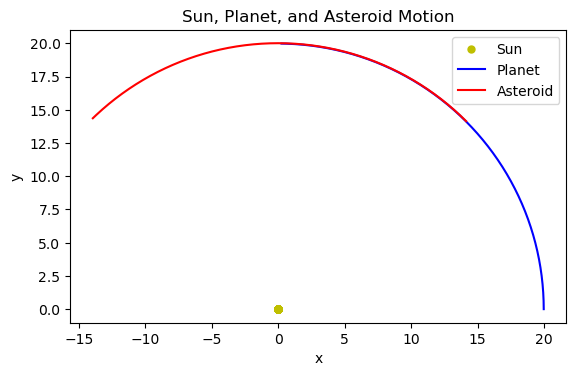

In [4]:
G  = 1.0
mS = 1e7 
mP = 1e4  
mA = 1.0  
R  = 20.0  

xS_pre = 0.0
xP_pre = R

xCM = (xP_pre*mP + xS_pre*mS) / (mS + mP)

xS = xS_pre - xCM
xP = xP_pre - xCM

rS = np.array([xS, 0.0])
rP = np.array([xP, 0.0])

theta = np.deg2rad(45)
rA = np.array([R*np.cos(theta), R*np.sin(theta)])

mu = (mS*mP)/(mS + mP)
omega = np.sqrt(G*mS*mP/(mu * R**3))

def perp_vel(r, omega):
    x, y = r
    return omega * np.array([-y, x])

vS = perp_vel(rS, omega)
vP = perp_vel(rP, omega)
vA = perp_vel(rA, omega)

y = np.array([
    rS[0], rS[1],
    rP[0], rP[1],
    rA[0], rA[1],
    vS[0], vS[1],
    vP[0], vP[1],
    vA[0], vA[1]
])

def ThreeBodyODE(t, y):
    global mS, mP, mA, G

    rS = y[0:2]
    rP = y[2:4]
    rA = y[4:6]

    vS = y[6:8]
    vP = y[8:10]
    vA = y[10:12]

    def Force(r1, r2, m1, m2):
        R = r2 - r1
        d = np.sqrt(R[0]**2 + R[1]**2)
        return G * m1 * m2 * R / d**3

    F_SP = Force(rS, rP, mS, mP)
    F_PS = -F_SP

    F_SA = Force(rS, rA, mS, mA)
    F_AS = -F_SA

    F_PA = Force(rP, rA, mP, mA)
    F_AP = -F_PA

    aS = (F_SP + F_SA) / mS
    aP = (F_PS + F_PA) / mP
    aA = (F_AS + F_AP) / mA

    drdt = np.array([
        vS[0], vS[1],
        vP[0], vP[1],
        vA[0], vA[1]
    ])

    dvdt = np.array([
        aS[0], aS[1],
        aP[0], aP[1],
        aA[0], aA[1]
    ])

    return np.concatenate((drdt, dvdt))

P = np.sqrt((4*np.pi**2 * R**3) / (G*(mS + mP)))

dt = P/1000
t_end = P/4
N = int(t_end / dt)

xS_arr = np.zeros(N)
yS_arr = np.zeros(N)
xP_arr = np.zeros(N)
yP_arr = np.zeros(N)
xA_arr = np.zeros(N)
yA_arr = np.zeros(N)

t = 0.0

for i in range(N):
    xS_arr[i] = y[0]
    yS_arr[i] = y[1]
    xP_arr[i] = y[2]
    yP_arr[i] = y[3]
    xA_arr[i] = y[4]
    yA_arr[i] = y[5]

    F1 = ThreeBodyODE(t, y)
    F2 = ThreeBodyODE(t + dt/2, y + dt*F1/2)
    F3 = ThreeBodyODE(t + dt/2, y + dt*F2/2)
    F4 = ThreeBodyODE(t + dt,   y + dt*F3)

    y = y + (dt/6)*(F1 + 2*F2 + 2*F3 + F4)
    t += dt

plt.plot(xS_arr, yS_arr, 'yo', ms=5, label="Sun")
plt.plot(xP_arr, yP_arr, 'b-', label="Planet")
plt.plot(xA_arr, yA_arr, 'r-', label="Asteroid")

plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Sun, Planet, and Asteroid Motion")
plt.show()


The trajectory that appears as a point is going to be the sun, because it is so massive it barely moves in comparison to the asteroid and the planet. the asteroid is the one in front because it is located at L4. The asteroid will also be a little wobbly as the orbit goes longer than just a quarter of a period. 

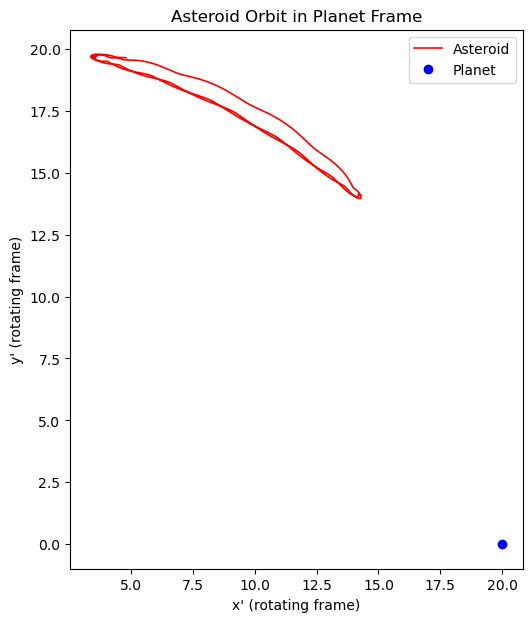

In [5]:
def TransformIntoPlanetFrame(xp, yp, x, y):
    phi = np.arctan2(yp, xp)
    s = np.sin(phi)
    c = np.cos(phi)

    A = np.array([[c, s],
                  [-s, c]])

    r  = np.array([x, y])
    rt = A.dot(r)

    return rt[0], rt[1]


t_end = 20 * P  
N = int(t_end / dt) 

xS_arr = np.zeros(N)
yS_arr = np.zeros(N)
xP_arr = np.zeros(N)
yP_arr = np.zeros(N)
xA_arr = np.zeros(N)
yA_arr = np.zeros(N)

xA_rot = np.zeros(N)
yA_rot = np.zeros(N)

t = 0.0

for i in range(N):
    xS_arr[i] = y[0]
    yS_arr[i] = y[1]
    xP_arr[i] = y[2]
    yP_arr[i] = y[3]
    xA_arr[i] = y[4]
    yA_arr[i] = y[5]

    xA_rot[i], yA_rot[i] = TransformIntoPlanetFrame(
        y[2], y[3],  
        y[4], y[5] 
    )

    F1 = ThreeBodyODE(t, y)
    F2 = ThreeBodyODE(t + dt/2, y + dt*F1/2)
    F3 = ThreeBodyODE(t + dt/2, y + dt*F2/2)
    F4 = ThreeBodyODE(t + dt,   y + dt*F3)

    y = y + (dt/6)*(F1 + 2*F2 + 2*F3 + F4)
    t += dt


plt.figure(figsize=(7,7))
plt.plot(xA_rot, yA_rot, 'r-', linewidth=1.2, label="Asteroid")

plt.plot(R, 0, 'bo', label="Planet")

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x' (rotating frame)")
plt.ylabel("y' (rotating frame)")
plt.title("Asteroid Orbit in Planet Frame")
plt.legend()
plt.show()


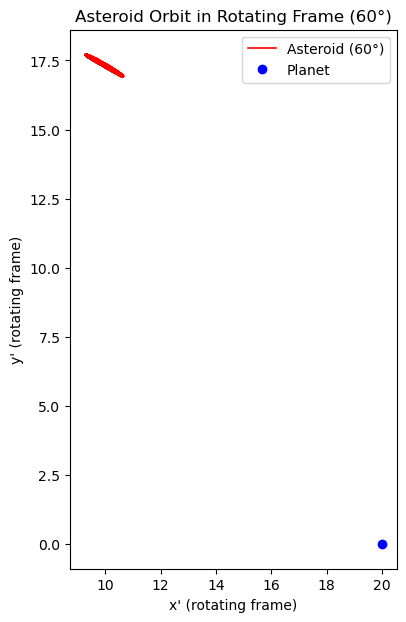

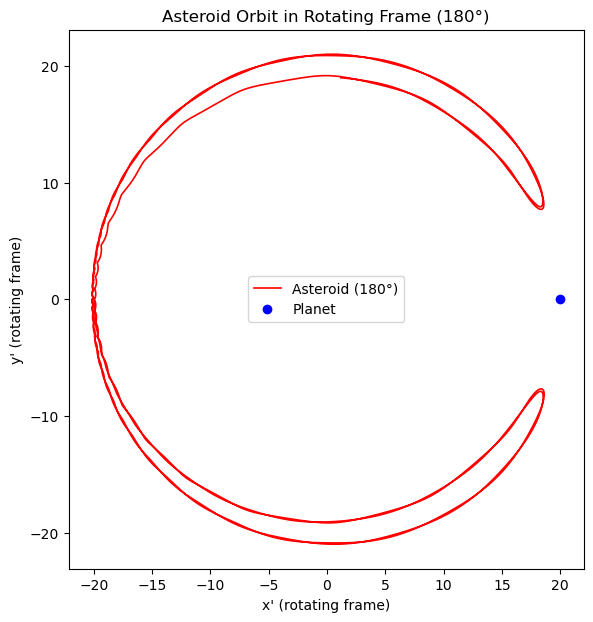

In [7]:
def simulate_with_angle(theta0_deg):

    theta0 = np.deg2rad(theta0_deg)

    rA = np.array([R*np.cos(theta0), R*np.sin(theta0)])
    vA = perp_vel(rA, omega)

    y = np.array([
        rS[0], rS[1],
        rP[0], rP[1],
        rA[0], rA[1],
        vS[0], vS[1],
        vP[0], vP[1],
        vA[0], vA[1]
    ])

    t_end = 100 * P
    N = int(t_end / dt)

    xA_rot = np.zeros(N)
    yA_rot = np.zeros(N)

    t = 0.0

    for i in range(N):
        xp, yp = y[2], y[3] 
        xA, yA = y[4], y[5] 

        xA_rot[i], yA_rot[i] = TransformIntoPlanetFrame(xp, yp, xA, yA)

        F1 = ThreeBodyODE(t, y)
        F2 = ThreeBodyODE(t + dt/2, y + dt*F1/2)
        F3 = ThreeBodyODE(t + dt/2, y + dt*F2/2)
        F4 = ThreeBodyODE(t + dt,   y + dt*F3)

        y = y + (dt/6)*(F1 + 2*F2 + 2*F3 + F4)
        t += dt

    plt.figure(figsize=(7,7))
    plt.plot(xA_rot, yA_rot, 'r-', linewidth=1.2,
             label=f"Asteroid ({theta0_deg}°)")

    plt.plot(R, 0, 'bo', label="Planet")

    plt.gca().set_aspect('equal')
    plt.xlabel("x' (rotating frame)")
    plt.ylabel("y' (rotating frame)")
    plt.title(f"Asteroid Orbit in Rotating Frame ({theta0_deg}°)")
    plt.legend()
    plt.show()

simulate_with_angle(60) 
simulate_with_angle(180) 